In [1]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [4]:
insurance_data=pd.read_csv('insurance.csv')

X=insurance_data.drop(columns=["charges",])
y=insurance_data["charges"]
X=pd.get_dummies(X,columns=["region"],drop_first=False, dtype=int)

X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

#adding two more column 
X["age_smoker"]=X["age"]*X["smoker"]
X["bmi_smoker"]=X["bmi"]*X["smoker"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

mean squre value for alpha=0.001:  20922596.52800621
mean squre value for alpha=1:  20915761.34772445
mean squre value for alpha=5:  20894930.88738715
mean squre value for alpha=2:  20909904.88284825
mean squre value for alpha=10:  20879460.429074317
mean squre value for alpha=20:  20885116.38537385
mean squre value for alpha=30:  20939554.097556505
mean squre value for alpha=40:  21030365.00375736
mean squre value for alpha=50:  21137371.396251045


<Axes: >

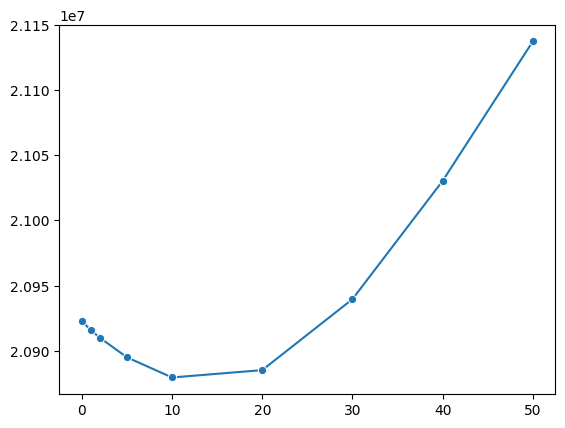

In [ ]:
#we have to check the best alpha value 
import seaborn as sns
alpha=[0.001,1,5,2,10,20,30,40,50]
mses=[]
for a in alpha:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_tarin,y_train)
    y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    print(f"mean squre value for alpha={a}: ",mse)
    mses.append(mse)
sns.lineplot(x=alpha,y=mses,marker="o")#no changes in these days 

In [ ]:
insurance_data.head()